# Depth Estimation with MATA

Demonstrates `DepthResult._repr_png_()` — depth maps render automatically
as a colourised PNG using the **magma** colormap.

**Model used**: `depth-anything/Depth-Anything-V2-Small-hf`

**Prerequisites**: `pip install datamata[notebook]`

In [1]:
# !pip install datamata[notebook]

In [2]:
import mata
print(f"MATA version: {mata.__version__}")

MATA version: 1.9.4


In [3]:
depth_model = mata.load("depth", "depth-anything/Depth-Anything-V2-Small-hf")

[INFO] Loading depth model from huggingface: depth-anything/Depth-Anything-V2-Small-hf


[INFO] Auto-selected CUDA device (NVIDIA GeForce RTX 3070)
[INFO] Initialized HuggingFaceDepthAdapter with device=cuda, threshold=0.0


d:\Documents\OneDrive\Code\mtp\datamata_io\mata\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[INFO] Loading HuggingFace depth model: depth-anything/Depth-Anything-V2-Small-hf
[INFO] Depth model loaded successfully on cuda


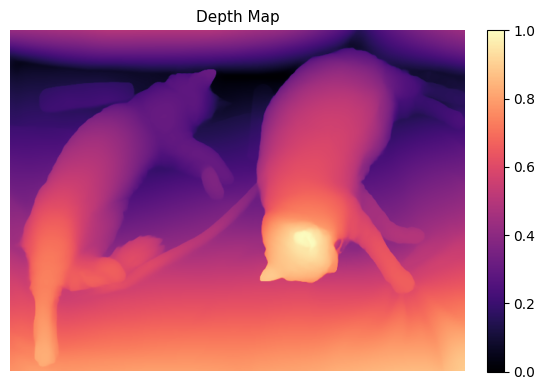

In [4]:
IMAGE = "../../examples/images/000000039769.jpg"
result = depth_model.predict(IMAGE)

# Auto-display: renders as magma colormap PNG inline
result

In [5]:
# Inspect the raw depth array
import numpy as np
print(f"Depth shape:      {result.depth.shape}")
print(f"Depth range:      [{result.depth.min():.3f}, {result.depth.max():.3f}]")
print(f"Normalized range: [{result.normalized.min():.3f}, {result.normalized.max():.3f}]")

Depth shape:      (480, 640)
Depth range:      [0.808, 5.159]
Normalized range: [0.000, 1.000]


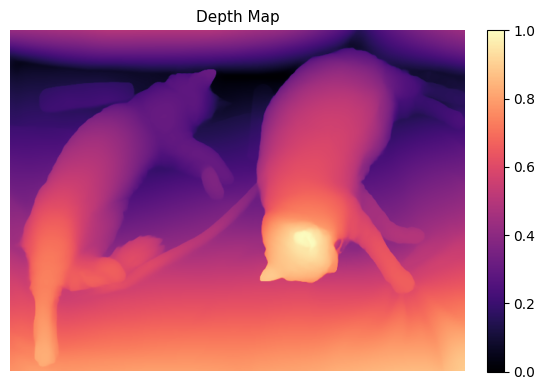

In [6]:
# Explicit display
mata.show(result)

## Notes

- `DepthResult` uses `_repr_png_()` (not `_repr_html_()`) for richer colour rendering
- The magma colormap highlights near objects in yellow/white and far objects in dark purple
- `result.depth` is the raw float array; `result.normalized` is scaled to `[0, 1]`